# 203.1. Survey property maps

<div style="max-width:300px; float: left; margin-right: 1em">

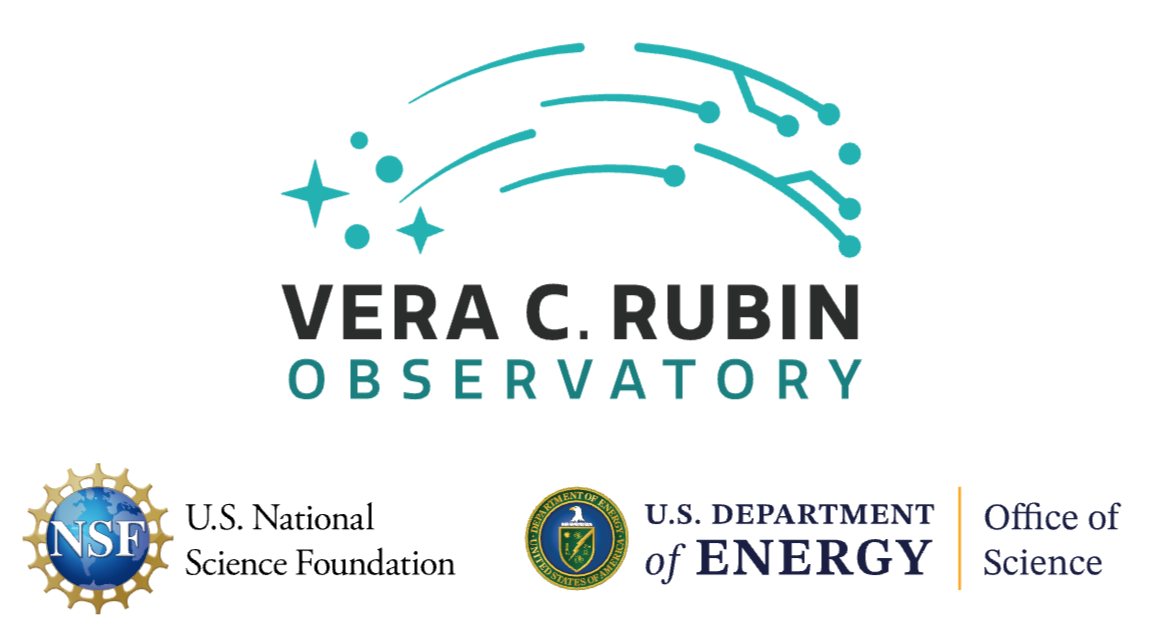

</div>

For the Rubin Science Platform at data.lsst.cloud. <br>
Data Release: <a href="https://dp1.lsst.io/">Data Preview 1</a> <br>
Container Size: large <br>
LSST Science Pipelines version: r29.2.0 <br>
Last verified to run: 2025-12-17 <br>
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a> <br>

**Learning objective:** To understand how to access and visualize the survey property maps.

**LSST data products:** Survey property maps.

**Packages:** `skyproj`, `lsst.daf.butler`

**Credit:**
Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This notebook will teach the user how to load and visualize survey property maps generated by the Rubin Science Pipelines.

The survey property maps are all-sky metrics such as total depth or mean image quality, aggregated from all the images.

The maps are available in the "healsparse" format.
The `healsparse` package, which is not used in this notebook,
provides utilities for reading and manipulating sparse healpix maps.
More information can be found in the documentation
"[HealSparse: A sparse implementation of HEALPix](https://healsparse.readthedocs.io/en/latest/)".

The map names, descriptions (and units if not dimensionless) are:

* `deepCoadd_exposure_time_consolidated_map_sum`: Total exposure time accumulated per sky position (second)
* `deepCoadd_epoch_consolidated_map_min, ...max, ...mean`: Earliest, latest, and mean observation epochs (MJD)
* `deepCoadd_psf_size_consolidated_map_weighted_mean`: Weighted mean of PSF characteristic width as computed from the determinant radius (pixel)
* `deepCoadd_psf_e1_consolidated_map_weighted_mean`: Weighted mean of PSF ellipticity component e1
* `deepCoadd_psf_e2_consolidated_map_weighted_mean`: Weighted mean of PSF ellipticity component e2
* `deepCoadd_psf_maglim_consolidated_map_weighted_mean`: Weighted mean of PSF flux 5σ magnitude limit (magAB)
* `deepCoadd_sky_background_consolidated_map_weighted_mean`: Weighted mean of background light level from the sky (nJy)
* `deepCoadd_sky_noise_consolidated_map_weighted_mean`: Weighted mean of standard deviation of the sky level (nJy)
* `deepCoadd_dcr_dra_consolidated_map_weighted_mean`: Weighted mean of DCR-induced astrometric shift in right ascension direction, expressed as a proportionality factor
* `deepCoadd_dcr_ddec_consolidated_map_weighted_mean`: Weighted mean of DCR-induced astrometric shift in declination direction, expressed as a proportionality factor
* `deepCoadd_dcr_e1_consolidated_map_weighted_mean`: Weighted mean of DCR-induced change in PSF ellipticity (e1), expressed as a proportionality factor
* `deepCoadd_dcr_e2_consolidated_map_weighted_mean`: Weighted mean of DCR-induced change in PSF ellipticity (e2), expressed as a proportionality factor

**Related tutorials:** The 100-level tutorials on how to use the Butler and display images.

### 1.1. Import packages

Import general python packages from `numpy`, `matplotlib`, and `astropy`, and the LSST Science Pipelines package for the Butler.
Also import the `skyproj` package, which provides utilities for visualizing both sparse and dense HEALPix maps, as described in the documentation "[SkyProj: Sky Projections with matplotlib and PROJ](https://skyproj.readthedocs.io/en/latest/)".

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval, LinearStretch, ImageNormalize
import skyproj
from lsst.daf.butler import Butler

### 1.2. Define parameters and functions

Instantiate the Butler.

In [ ]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
assert butler is not None

Use the Extended Chandra Deep Field South (ECDFS) field.
Define the central coordinates of the field to use throughout.

In [ ]:
ra_cen = 53.13
dec_cen = -28.10

## 2. Data access

Survey property maps are available via the Butler.

### 2.1. List all maps

Use the Butler to print a list of the available maps.

In [ ]:
for dtype in sorted(butler.registry.queryDatasetTypes(expression="*consolidated_map*")):
    print(dtype.name)

Each of these products represents a healsparse map containing the value of an individual survey property,
as described in Section 1.

Show the dataset type for one of the maps.

In [ ]:
butler.get_dataset_type("deepCoadd_dcr_ddec_consolidated_map_weighted_mean")

Show that the required dimensions for retrieving this map are the skymap and the band.

In [ ]:
butler.get_dataset_type("deepCoadd_dcr_ddec_consolidated_map_weighted_mean").dimensions.required

### 2.2. Retrieve a map

Retrieve a map from the Butler by specifying the map name and band: select the PSF magnitude limits in r-band.

In [ ]:
hspmap = butler.get('deepCoadd_psf_maglim_consolidated_map_weighted_mean',
                    band='r')

## 3. Manipulate the map

To conserve memory, HealSparse uses a dual-map approach, where a low-resolution full-sky “coverage map” is combined with a high resolution map containing the pixel data where it is available.

Show that the map has been provided as a `HealSparseMap` object.

In [ ]:
hspmap

### 3.1. Get map value at position

Each pixel of the healsparse map corresponds to a small region of the sky.
The value of the map corresponds to the value of the survey property at that location.

To access the survey property value at a specific location or set of locations, query for the map value using the `get_values_pos` functionality.

Print the map value at the center of the ECDFS field.

In [ ]:
print(hspmap.get_values_pos(ra_cen, dec_cen))

Extract map values at an array of locations over a small area near the center of the ECDFS field.

In [ ]:
span_dec = 0.25
span_ra = span_dec / np.cos(np.deg2rad(dec_cen))
ra = np.linspace(ra_cen-span_ra, ra_cen+span_ra, 3)
dec = np.linspace(dec_cen-span_dec, dec_cen+span_dec, 3)
print('RA: ', ra)
print('Dec: ', dec)
for d in dec:
    print(hspmap.get_values_pos(ra, d))
del ra, dec

A sentinel (placeholder) value is returned if the position is outside the region where the map has data.

Request the map value at a northern declination, and see the sentinel value.

In [ ]:
print(hspmap.get_values_pos(180, +30))

### 3.2. Get map statistics in region

Extract map values over the full region of the ECDFS field.

In [ ]:
span_dec = 0.75
span_ra = span_dec / np.cos(np.deg2rad(dec_cen))
ra = np.linspace(ra_cen-span_ra, ra_cen+span_ra, 250)
dec = np.linspace(dec_cen-span_dec, dec_cen+span_dec, 250)
x, y = np.meshgrid(ra, dec)
values = hspmap.get_values_pos(x, y)

Change map values with the sentinel value from the placeholder to "Not a Number" (NaN), so they don't contribute to the statistical measures.

In [ ]:
row, col = np.where(values < 0.0)
values[row, col] = 'NaN'

Print a few statistics on the map values.

In [ ]:
print(np.nanmin(values), np.nanmax(values))
print(np.nanmean(values), np.nanstd(values))
print(np.nanmedian(values))

## 4. Visualize the map

Plot the map values in the ECDFS region with the `pcolormesh` functionality and include a colorbar. Invert the x-axis so that the plot is east-left.

In [ ]:
fig = plt.figure(figsize=(6, 5))
plt.pcolormesh(x, y, values)
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.colorbar(label="PSF Mag Limit (r-band)")
plt.gca().invert_xaxis()
plt.show()

> **Figure 1:** The survey property map for PSF magnitude limit in the r-band for the ECDFS field.

### 4.1. Scale and color

Set the `vmin` and `vmax` values to produce a map that clearly delineates the region where the r-band image depth is greater than 25 magnitudes.

In [ ]:
fig = plt.figure(figsize=(6, 5))
plt.pcolormesh(x, y, values, vmin=24.9, vmax=25.0)
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.colorbar(label="PSF Mag Limit (r-band)")
plt.gca().invert_xaxis()
plt.show()

> **Figure 2:** Same data as Figure 1, but with the minimum and maximum values of the color bar set at 24.9 and 25.0 magnitudes.

Create a black-and-white plot using the "Greys" colormap (`cmap`).

In [ ]:
fig = plt.figure(figsize=(6, 5))
plt.pcolormesh(x, y, values, cmap="Greys")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.colorbar(label="PSF Mag Limit (r-band)")
plt.gca().invert_xaxis()
plt.show()

> **Figure 3:** The same data as in Figure 1, but displayed with a greyscale colormap.

### 4.2. Sky projections

The `skyproj` package provides more advanced plotting capabilities.

Display the all-sky map with a grid.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
sp = skyproj.Skyproj(ax=ax)
sp.draw_hspmap(hspmap)
# sp.draw_colorbar(label='PSF Maglim (r-band)')
plt.show()
del fig, ax, sp

> **Figure 4:** The all-sky r-band PSF depth map for Data Preview 1 shows the 7 fields.

In Figure 4, notice how the 47 Tuc field at lower right (RA~6) is "stretched" out with this linear grid.
This grid is not a good representation of the curved sky.

Display the all-sky map with the `McBrydeSkyproj`. This creates a visualization using the McBryde-Thomas Flat Polar Quartic projection, centered at 56 deg RA (because the DP1 fields range from 6 to 106 degrees in RA).

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sp = skyproj.McBrydeSkyproj(ax=ax, lon_0=56.0)
sp.draw_hspmap(hspmap)
sp.draw_colorbar(label='PSF Maglim (r-band)')
plt.show()
del fig, ax, sp

> **Figure 5:** The same data as Figure 4, but with a McBryde sky projection that is more appropriate for the curved plane of the sky.

## 5. Co-plot maps and deep coadd

Build a four-panel plot that shows one deep coadd image, side-by-side with three survey property maps covering the same region.

Find a `deep_coadd` image that overlaps the central RA and Dec of the ECDFS field, defined in Section 1.2.

In [ ]:
query = f"band.name = 'r' AND patch.region OVERLAPS POINT({ra_cen}, {dec_cen})"
print(query)
refs = butler.query_datasets("deep_coadd",
                             where=query,
                             order_by=["patch.tract"])
print(len(refs))

Retrieve the image.

In [ ]:
deep_coadd = butler.get(refs[0])

Get the WCS and bounding box, and define the extent and corners of the image.

In [ ]:
wcs = deep_coadd.getWcs()
bbox = deep_coadd.getBBox()

In [ ]:
extent = (bbox.beginX, bbox.endX, bbox.beginY, bbox.endY)
corners = [wcs.pixelToSky(bbox.beginX, bbox.beginY),
           wcs.pixelToSky(bbox.beginX, bbox.endY),
           wcs.pixelToSky(bbox.endX, bbox.endY),
           wcs.pixelToSky(bbox.endX, bbox.beginY)]

Option to display the `deep_coadd` image on its own.

In [ ]:
# from astropy.wcs import WCS
# temp = deep_coadd.image.array.flatten()
# norm = ImageNormalize(temp, interval=ZScaleInterval(),
#                       stretch=LinearStretch())
# fig = plt.figure()
# plt.subplot(projection=WCS(wcs.getFitsMetadata()))
# im = plt.imshow(deep_coadd.image.array, cmap='gray', norm=norm,
#                 extent=extent, origin='lower')
# plt.grid(color='white', ls='solid')
# plt.xlabel('Right Ascension')
# plt.ylabel('Declination')
# plt.show()
# del fig, im, temp, norm

Retrieve two more survey property maps:
the weighted mean of the PSF size,
and the weighted mean sky background,
both in r-band.

In [ ]:
hspmap_psf = butler.get('deepCoadd_psf_size_consolidated_map_weighted_mean',
                        band='r')
hspmap_sky = butler.get('deepCoadd_sky_background_consolidated_map_weighted_mean',
                        band='r')

Make a new grid that matches the boundaries of the `deep_coadd` image.

In [ ]:
lower = wcs.pixelToSky(bbox.beginX, bbox.beginY)
upper = wcs.pixelToSky(bbox.endX, bbox.endY)
ra = np.linspace(lower.getRa().asDegrees(),
                 upper.getRa().asDegrees(), 150)
dec = np.linspace(lower.getDec().asDegrees(),
                  upper.getDec().asDegrees(), 150)
x, y = np.meshgrid(ra, dec)

It's challenging to overlay a projected RA, Dec grid in a subplot.
Instead, prepare to substitute pixels for sky coordinates as tick labels for the image.

In [ ]:
xtick_locs = np.linspace(extent[0], extent[1], 5)
ytick_locs = np.linspace(extent[2], extent[3], 5)
xtick_lbls = []
ytick_lbls = []
for xt, yt in zip(xtick_locs, ytick_locs):
    temp = wcs.pixelToSky(xt, yt)
    xtick_lbls.append(str(np.round(temp.getRa().asDegrees(), 2)))
    ytick_lbls.append(str(np.round(temp.getDec().asDegrees(), 2)))

Create the four-panel figure.

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(9, 6))

temp = deep_coadd.image.array.flatten()
norm = ImageNormalize(temp, interval=ZScaleInterval(),
                      stretch=LinearStretch())
im = ax[0, 0].imshow(deep_coadd.image.array, cmap='gray', norm=norm,
                     extent=extent, origin='lower')
fig.colorbar(im, ax=ax[0, 0], label="Pixel Value (r-band)")
ax[0, 0].set_xticks(xtick_locs, xtick_lbls)
ax[0, 0].set_yticks(ytick_locs, ytick_lbls)
ax[0, 0].axis('tight')

values = hspmap.get_values_pos(x, y)
pcm = ax[0, 1].pcolormesh(x, y, values, cmap='viridis')
fig.colorbar(pcm, ax=ax[0, 1], label="PSF Mag Limit (r-band)")
ax[0, 1].axis('tight')
ax[0, 1].invert_xaxis()
del pcm, values

values = hspmap_psf.get_values_pos(x, y)
pcm = ax[1, 0].pcolormesh(x, y, values, cmap='plasma')
fig.colorbar(pcm, ax=ax[1, 0], label="PSF Size (r-band)")
ax[1, 0].axis('tight')
ax[1, 0].invert_xaxis()
del pcm, values

values = hspmap_sky.get_values_pos(x, y)
pcm = ax[1, 1].pcolormesh(x, y, values, cmap='cividis')
fig.colorbar(pcm, ax=ax[1, 1], label="Sky Background (r-band)")
ax[1, 1].axis('tight')
ax[1, 1].invert_xaxis()
del pcm, values

plt.tight_layout()

del fig, ax, temp, norm

> **Figure 6:** Four different views on the DP1 ECDFS field: the $r$-band deep coadd image pixel data (grayscale, upper left);
> the $r$-band PSF magnitude limit (viridis, upper right); the $r$-band PSF size (plasma, lower left);
> and the $r$-band sky background (cividis, lower right).